# 

In [2]:
# !pip uninstall -y oceanttds

In [3]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path('.cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(Path('.cache/matplotlib').resolve()))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
# import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import jax
import jax.numpy as jnp
import numpyro
import xarray_jax  # noqa: F401 - registers xarray objects as JAX pytrees
from numpyro import distributions as dist, sample
from numpyro.infer import MCMC, NUTS, Predictive
numpyro.set_host_device_count(4)
jax.local_device_count()


4

In [4]:
import cmocean.cm as cmo

In [17]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bayesian_inverse_gaussian_results.nc"
merged_bayes_ds = xr.open_dataset(ds_path)

In [41]:
from plot_ig_utils import *
from utils import *

bayes_integrator = TTDIntegrator(order=61)

In [66]:
prior = merged_bayes_ds.sel(distribution = "prior")
posterior = merged_bayes_ds.sel(distribution = "posterior")

ds_i =  merged_bayes_ds[[v for v in merged_bayes_ds if "interior_time" in merged_bayes_ds[v].dims]].rename({"interior_time":"time"})
ds_b =  merged_bayes_ds[[v for v in merged_bayes_ds if "boundary_time" in merged_bayes_ds[v].dims]].rename({"boundary_time":"time"})

In [76]:
expt_colors = {"forced":"r", "control":"b"}
variable_units = {"cfc11":r"pmol kg$^{-1}$", "cfc12":r"pmol kg$^{-1}$", "sf6":r"fmol kg$^{-1}$"}

In [78]:
prior_da = bayes_integrator.predict_sources(
    gamma=prior['gamma'], delta=prior['delta'], mass_fraction=prior['mass_fraction'],
    obs_times=ds_i['time'], boundary_time=ds_b['time'], boundary=ds_b['boundary'],
)
posterior_da = bayes_integrator.predict_sources(
    gamma=posterior['gamma'], delta=posterior['delta'], mass_fraction=posterior['mass_fraction'],
    obs_times=ds_i['time'], boundary_time=ds_b['time'], boundary=ds_b['boundary'],
)

for expt in ds_b.expt.values:
    posterior_mse = mse_score(posterior_da.sel(expt = expt), ds_i['interior'].sel(expt = expt),  ds_i['sigma_obs'].sel(expt = expt))
    print(
        f'{expt}: posterior predictive RMSE = '
        f"{float(posterior_mse['rmse'].quantile(0.5)):.4g} "
        f"[{float(posterior_mse['rmse'].quantile(0.025)):.4g}, {float(posterior_mse['rmse'].quantile(0.975)):.4g}]"
    )

control: posterior predictive MSE = 1.268 [1.26, 1.287]
control: posterior predictive RMSE = 1.126 [1.122, 1.134]
forced: posterior predictive MSE = 7.366 [7.358, 7.384]
forced: posterior predictive RMSE = 2.714 [2.713, 2.717]


In [188]:
tau_plot = xr.DataArray(np.geomspace(0.1, 20000.0, 300), dims='tau', name='tau', attrs={'units': 'years'})
prior_components = xr_pdf(InverseGaussian, gamma=prior['gamma'], delta=prior['delta'])(tau_plot)
posterior_components = xr_pdf(InverseGaussian, gamma=posterior['gamma'], delta=posterior['delta'])(tau_plot)
prior_age_samples = (prior['mass_fraction'] * prior_components).sum('source')
posterior_age_samples = (posterior['mass_fraction'] * posterior_components).sum('source')

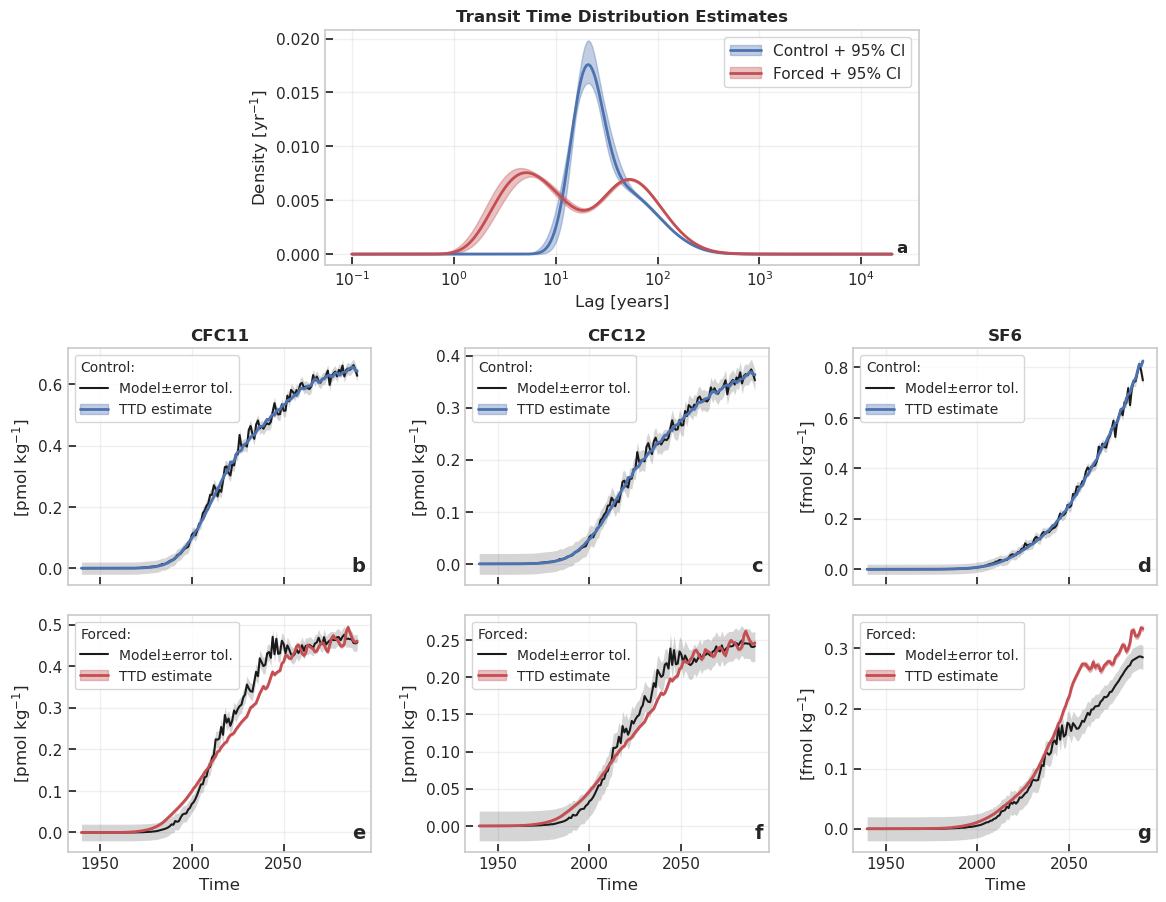

In [189]:
import string
import matplotlib.pyplot as plt
import seaborn as sns


def plot_error_band(ax, time, history, error, label, color, legend=None, alpha=0.25):
    legend = {} if legend is None else legend

    ax.fill_between(time, history - 2 * error, history + 2 * error,
                    color=color, alpha=alpha, linewidth=0)
    line, = ax.plot(time, history, color=color)

    legend[label] = line
    return legend


sns.set_theme(style="whitegrid", context="notebook")

expts, tracers = list(ds_b.expt.values), list(ds_i.tracer.values)
nrows, ncols = len(expts) + 1, len(tracers)

fig = plt.figure(figsize=(3.5 * ncols * 1.1, 2.7 * nrows * 1.1), constrained_layout=True)
gs = fig.add_gridspec(nrows, ncols, height_ratios=[1.3] + [1.0] * len(expts),
                      hspace=0.1, wspace=0.07)

gs_ttd = gs[0, :].subgridspec(
    1, ncols + 2,
    width_ratios=[0.6] + [0.5] * ncols + [0.6],
)

ax_ttd = fig.add_subplot(gs_ttd[0, 1:-1])
ttd_legend = {}

for expt in expts:
    plot_distribution(ax_ttd, tau_plot, posterior_age_samples.sel(expt=expt),
                      expt_colors[str(expt)], f"{str(expt).capitalize()} + 95% CI",
                      legend=ttd_legend)

ax_ttd.set(xscale="log", title="Transit Time Distribution Estimates",
           xlabel="Lag [years]", ylabel=r"Density [yr$^{-1}$]")
ax_ttd.title.set_fontweight("bold")
ax_ttd.grid(alpha=0.7)
ax_ttd.legend(ttd_legend.values(), ttd_legend.keys())
ax_ttd.text(0.98, 0.04, "a", transform=ax_ttd.transAxes,
            ha="right", va="bottom", fontweight="bold")

ax_ref = None
panel_letters = iter(string.ascii_lowercase[1:])

for row, expt in enumerate(expts, start=1):
    color = expt_colors[str(expt)]

    for col, tracer in enumerate(tracers):
        ax = fig.add_subplot(gs[row, col], sharex=ax_ref)
        ax_ref = ax if ax_ref is None else ax_ref

        tracer = str(tracer)
        units = variable_units.get(tracer, "concentration")
        legend = {}

        plot_error_band(ax, ds_i.time,
                        ds_i.interior.sel(tracer=tracer, expt=expt),
                        ds_i.sigma_obs.sel(tracer=tracer, expt=expt),
                        r"Model±error tol.", truth_color, legend=legend, alpha=0.18)

        plot_distribution(ax, ds_i.time,
                          posterior_da.sel(tracer=tracer, expt=expt),
                          color, "TTD estimate", legend=legend)

        ax.set_ylabel(f"[{units}]")
        ax.grid(alpha=0.7)
        ax.legend(
            legend.values(), legend.keys(),
            title=str(expt).capitalize() + ":",
            fontsize=10,
            title_fontsize=10,
            alignment="left",
        )

        if row == 1:
            ax.set_title(str(tracer).upper(), fontweight="bold")
        if row == len(expts):
            ax.set_xlabel("Time")
        else:
            ax.tick_params(labelbottom=False)

        ax.text(0.98, 0.04, next(panel_letters), transform=ax.transAxes,
                ha="right", va="bottom", fontweight="bold", fontsize=14)

for ax in fig.axes:
    ax.grid(alpha = 0.3)
    ax.tick_params(direction="in", bottom=True, left=True,
                   top=False, right=False)

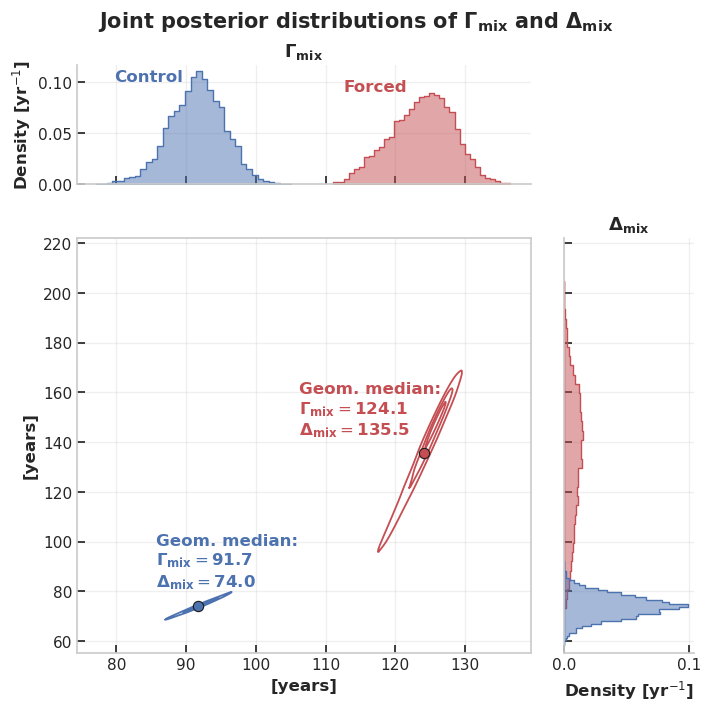

In [190]:
fig = plt.figure(figsize=(7.0, 7.0), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=(4.0, 1.15),
                      height_ratios=(1.15, 4.0), wspace=0.06, hspace=0.06)

ax_g = fig.add_subplot(gs[0, 0])
ax_j = fig.add_subplot(gs[1, 0], sharex=ax_g)
ax_d = fig.add_subplot(gs[1, 1], sharey=ax_j)

def get_gamma_delta(expt):
    p = posterior.sel(expt=expt)
    g, d = np.asarray(p["gamma_mix"]).ravel(), np.asarray(p["delta_mix"]).ravel()
    keep = np.isfinite(g) & np.isfinite(d)
    return g[keep], d[keep]

hist = lambda **k: sns.histplot(bins=35, stat="density", element="step",
                                alpha=0.5, fill=True, common_norm=False, **k)

kde = lambda g, d, c: sns.kdeplot(x=g, y=d, levels=(0.50, 0.80, 0.95),
                                  fill=False, thresh=0.0, color=c,
                                  linewidths=1.3, ax=ax_j)

offsets = {"forced": (-90, 10), "control": (-30, 11)}
gamma_label_y = {"forced": 0.82, "control": 0.90}


gamma_text = r"\mathbf{\Gamma_{\mathbf{mix}}}"
delta_text = r"\mathbf{\Delta_{\mathbf{mix}}}"
for expt in ("forced", "control"):
    color = expt_colors[expt]
    gamma, delta = get_gamma_delta(expt)
    gamma_med, delta_med = compute_geometric_median(np.column_stack([gamma, delta])).median

    hist(x=gamma, color=color, ax=ax_g)
    hist(y=delta, color=color, ax=ax_d)
    kde(gamma, delta, color)

    ax_j.scatter(gamma_med, delta_med, s=55, color=color, edgecolor="k",
                 linewidth=0.8, zorder=10)
    ax_j.annotate("Geom. median:\n" + rf"${gamma_text}=${gamma_med:.1f}" + "\n" + rf"${delta_text}=${delta_med:.1f}",
                  xy=(gamma_med, delta_med), xytext=offsets[expt],
                  textcoords="offset points", ha="left", fontweight = "bold", 
                  va="bottom" if offsets[expt][1] >= 0 else "top",
                  fontsize=12, color=color)

    ax_g.annotate(expt.capitalize(), xy=(np.nanmedian(gamma) - 7, gamma_label_y[expt]),
                  xycoords=("data", "axes fraction"), ha="center", va="center",
                  fontsize=12, fontweight="bold", color=color)

ax_g.set(title=r"$\mathbf{\Gamma_{\mathbf{mix}}}$",
         ylabel=r"Density [yr$^{-1}$]")
ax_d.set(title=r"$\mathbf{\Delta_{\mathbf{mix}}}$",
         xlabel=r"Density [yr$^{-1}$]")
ax_j.set(xlabel=r"[years]",
         ylabel=r"[years]")

ax_g.tick_params(labelbottom=False)
ax_d.tick_params(labelleft=False)

for ax in (ax_g, ax_d):
    ax.title.set(fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

for label in (ax_g.yaxis.label, ax_d.xaxis.label, ax_j.xaxis.label, ax_j.yaxis.label):
    label.set_fontweight("bold")
[a.grid(alpha = 0.3) for a in [ax_g, ax_d, ax_j]]

fig.suptitle(rf"Joint posterior distributions of ${gamma_text}$ and ${delta_text}$",
             fontsize=15, fontweight="bold")
for ax in fig.axes:
    ax.tick_params(direction="in", bottom=True, left=True,
                   top=False, right=False)

In [206]:
percent = xr.DataArray(
    np.arange(0.0, 50.0 + 2.5, 1.0),
    dims="percent",
    name="percent",
    attrs={"units": "%"},
)

ventilation_fraction = percent / 100.0


def ventilation_time_from_pdf_samples(pdf, fraction):
    cdf = pdf.cumulative_integrate("tau")
    cdf = cdf / cdf.isel(tau=-1)

    out = xr.apply_ufunc(
        np.interp,
        fraction,
        cdf,
        cdf["tau"],
        input_core_dims=[["percent"], ["tau"], ["tau"]],
        output_core_dims=[["percent"]],
        vectorize=True,
        output_dtypes=[float],
    )

    return out.assign_coords(percent=percent)


ventilation_time_prior = ventilation_time_from_pdf_samples(
    prior_age_samples,
    ventilation_fraction,
)

ventilation_time_posterior = ventilation_time_from_pdf_samples(
    posterior_age_samples,
    ventilation_fraction,
)

In [ ]:
source = ds_b.source.values[0]
fig, ax = plt.subplots(figsize=(8, 4.5))
legend = {}
plot_distribution(
    ax,
    percent,
    ventilation_time_posterior.sel(expt="control"),
    expt_colors['control'],
    'Control',
    legend=legend,
)
plot_distribution(
    ax,
    percent,
    ventilation_time_posterior.sel(expt="forced"),
    expt_colors['forced'],
    'Forced',
    legend=legend,
)
ax.axvline(10.0, color='0.5', lw=1, alpha=0.5)
ax.set_title('Ventilation Time Curve', fontweight='bold')
ax.set_xlabel('Cumulative Fraction (%)')
ax.set_ylabel('Ventilation Time (years)')
ax.grid(alpha=0.4)
ax.legend(legend.values(), legend.keys())
fig.tight_layout()